# Part 2: Classification and Model Improvement
## Breast Cancer Diagnostic Analysis

### ST10500865
### Kamogelo Motau

**Objective:** Develop a classification model to predict breast cancer diagnosis (Malignant vs. Benign) to expedite the processing of a medical aid scheme's "dread disease" benefit.

## 1. Dataset Selection and Justification

**Dataset Source:** [Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

**Justification for Choice:**
- **Relevance:** The dataset is specifically designed for binary classification of breast tumors as Malignant (M) or Benign (B), directly matching the client's need to predict cancer diagnosis.
- **Quality:** The dataset contains 569 samples with 30 numerical features derived from digitized cell nuclei images. There are no missing values in the primary dataset, making it ready for analysis.
- **Suitability:** The features are all numerical and continuous, making them directly usable for classification algorithms without complex encoding. The dataset is a standard benchmark in medical ML, allowing for performance comparison.

## 2. Algorithm Selection Justification

Four classification algorithms were selected for comparison:

1.  **Logistic Regression:** A simple, interpretable linear model that provides a strong baseline. It is efficient and offers feature coefficients that can be directly interpreted.
2.  **K-Nearest Neighbors (KNN):** A non-parametric, instance-based learner capable of modeling complex decision boundaries. It was chosen for its simplicity and to compare its distance-based approach against other methods.
3.  **Support Vector Machine (SVM):** A powerful classifier that finds the optimal separating hyperplane. SVMs are effective in high-dimensional spaces and, with the RBF kernel, can capture non-linear relationships.
4.  **Random Forest:** An ensemble method that builds multiple decision trees and averages their predictions. It is robust to outliers and feature scaling, handles non-linear data well, and provides feature importance scores for interpretation.

## 3. Analysis Plan

### a. Exploratory Data Analysis (EDA)
1.  Load the dataset and perform an initial inspection for shape, data types, and missing values.
2.  Analyze the target variable distribution to identify class imbalance.
3.  Use univariate analysis (histograms, boxplots) to understand the distribution of key numerical features.
4.  Use bivariate analysis (violin plots) to visualize how features differ between Malignant and Benign classes.
5.  Generate a correlation heatmap to identify multicollinearity among features.

### b. Feature Selection
1.  Drop the non-predictive `id` column.
2.  Reduce multicollinearity by automatically removing one feature from any pair with correlation > 0.95.
3.  Apply Recursive Feature Elimination (RFE) with a Random Forest estimator to select the 10 most important features for final modeling.

### c. Model Training
1.  Split the data into 80% training and 20% testing sets with stratification.
2.  Standardize features using `StandardScaler` (essential for Logistic Regression, KNN, SVM).
3.  Train Logistic Regression, KNN (with hyperparameter tuning), SVM (with hyperparameter tuning), and Random Forest models.

### d. Interpretation and Evaluation
The following metrics will be used to evaluate and compare models, with a focus on the performance of the Malignant (1) class:
-   **Accuracy:** Overall correctness.
-   **Precision (Malignant):** Of all predicted Malignant cases, how many were correct?
-   **Recall (Malignant):** Of all actual Malignant cases, how many were correctly identified?
-   **F1-Score (Malignant):** The harmonic mean of precision and recall.
-   **ROC-AUC:** The model's ability to distinguish between classes across all thresholds.
-   **Confusion Matrix:** To visualize true/false positives and negatives.

### e. Report Plan
A final report will be produced summarizing the data quality, key EDA findings, feature selection process, model performance, and a final interpretation and recommendation for the client.

In [13]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 4. Conducting the Analysis

### 4a. Exploratory Data Analysis (EDA)

In [3]:
# Load the dataset
df = pd.read_csv('data.csv')

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (569, 33)

First 5 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum().sum())

# Check data types
print("\nData types:")
print(df.dtypes.value_counts())

Missing values per column:
569

Data types:
float64    31
int64       1
object      1
Name: count, dtype: int64


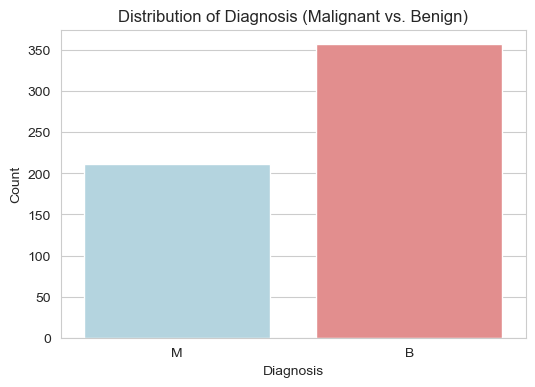

diagnosis
B    357
M    212
Name: count, dtype: int64


In [5]:
# Analyze the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, palette=['lightblue', 'lightcoral'])
plt.title('Distribution of Diagnosis (Malignant vs. Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

print(df['diagnosis'].value_counts())

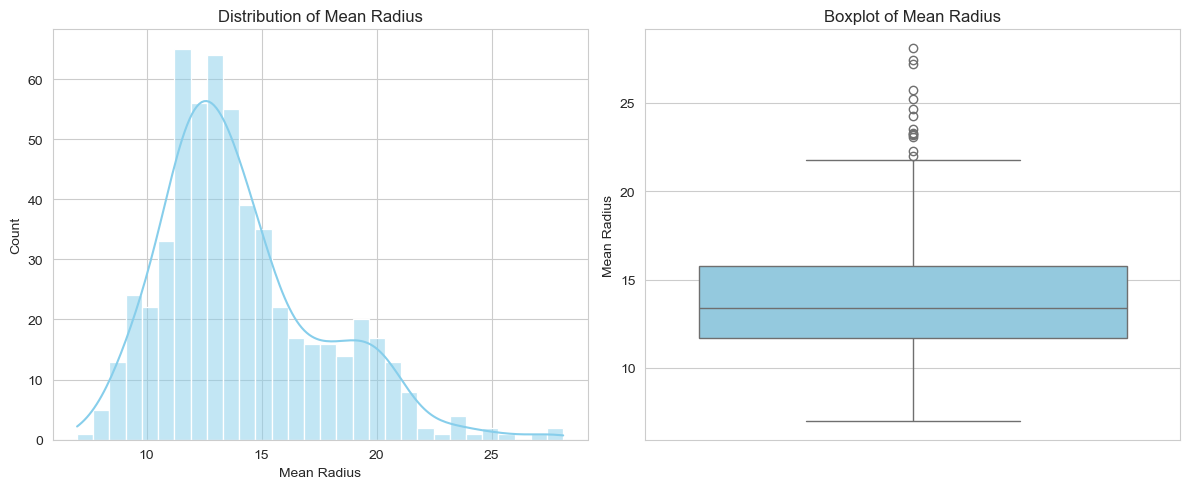

In [6]:
# Univariate analysis: Distribution of radius_mean
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['radius_mean'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Mean Radius')
plt.xlabel('Mean Radius')

plt.subplot(1, 2, 2)
sns.boxplot(y='radius_mean', data=df, color='skyblue')
plt.title('Boxplot of Mean Radius')
plt.ylabel('Mean Radius')
plt.tight_layout()
plt.show()

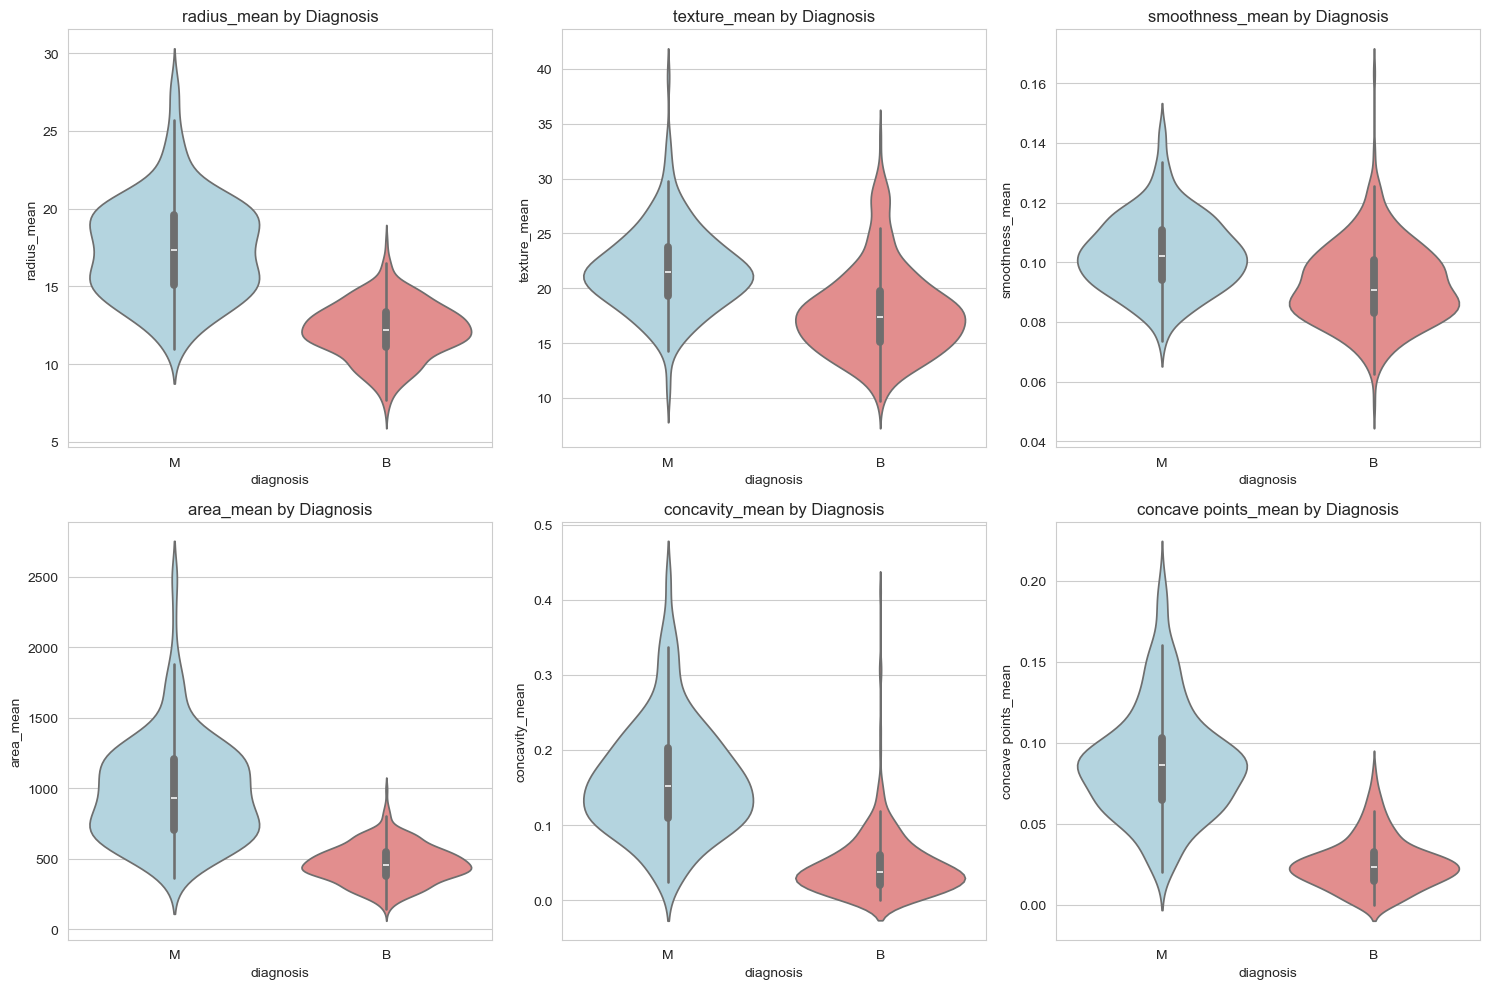

In [7]:
# Bivariate analysis: Features vs Diagnosis
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['radius_mean', 'texture_mean', 'smoothness_mean', 'area_mean', 'concavity_mean', 'concave points_mean']
for i, feature in enumerate(features):
    sns.violinplot(x='diagnosis', y=feature, data=df, palette=['lightblue', 'lightcoral'], ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'{feature} by Diagnosis')
plt.tight_layout()
plt.show()

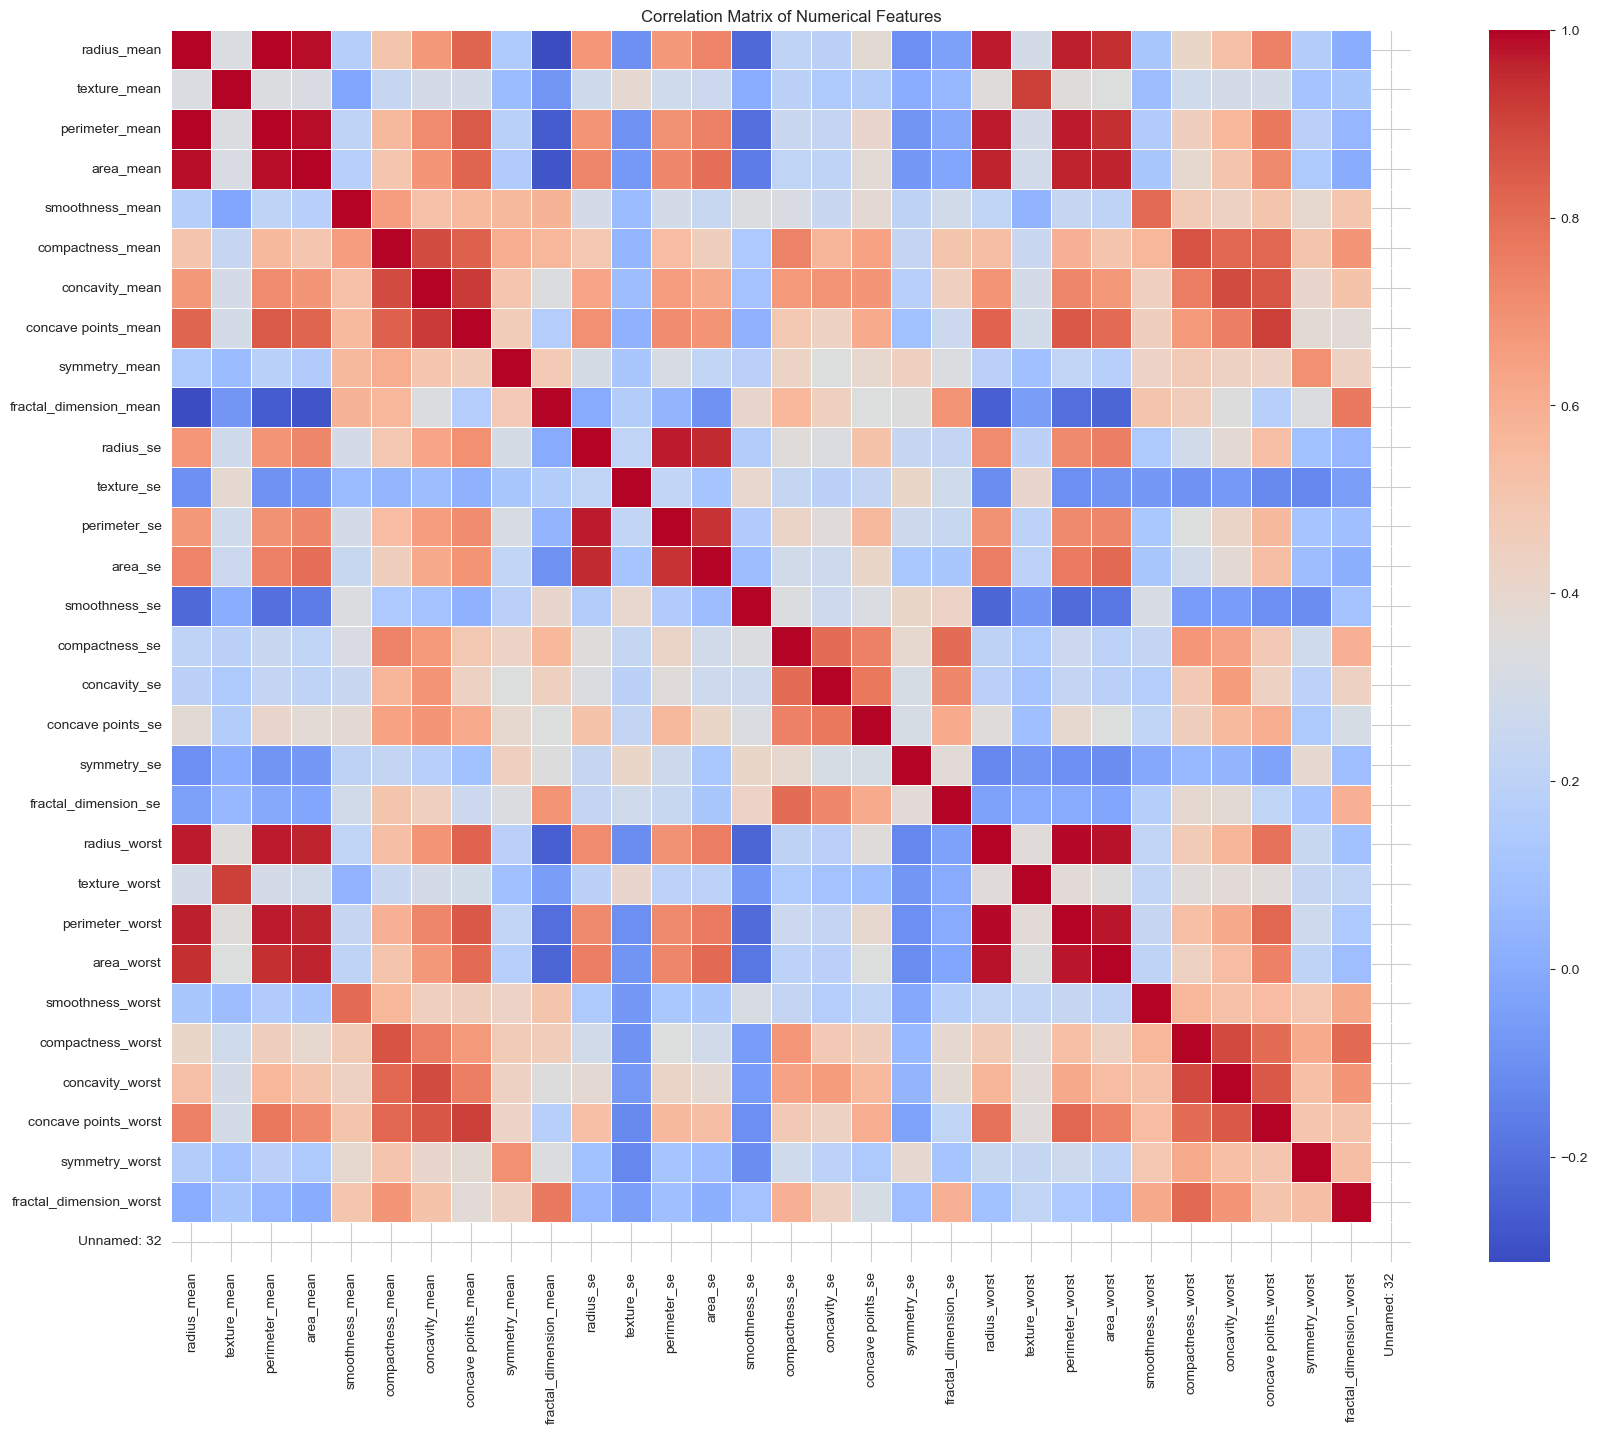

In [8]:
# Correlation analysis
correlation_matrix = df.drop(columns=['id', 'diagnosis']).corr()
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### 4b. Feature Selection

In [9]:
# Drop 'id' column and separate X and y
df_model = df.drop(columns=['id'])
X = df_model.drop('diagnosis', axis=1)
y = df_model['diagnosis'].map({'B': 0, 'M': 1})  # Encode target

# Function to remove highly correlated features
def remove_highly_correlated_features(X, threshold=0.95):
    corr_matrix = X.corr().abs()
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
    return X.drop(columns=to_drop), to_drop

# Apply correlation reduction
X_reduced, dropped_features = remove_highly_correlated_features(X)

print(f"Original number of features: {X.shape[1]}")
print(f"Number of features after removing multicollinear ones: {X_reduced.shape[1]}")
print("Dropped features:", dropped_features)

Original number of features: 31
Number of features after removing multicollinear ones: 24
Dropped features: ['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst']


In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for interpretability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### 4c. Model Training and Hyperparameter Tuning

In [15]:
# Define models and hyperparameter grids
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42)
}

param_grids = {
    "K-Nearest Neighbors": {'n_neighbors': [3, 5, 7, 9, 11]},
    "Support Vector Machine": {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}
}

# Handle missing values by imputing with median values
imputer = SimpleImputer(strategy='median')  # You can also use 'mean' or 'most_frequent'
X_train_imputed = imputer.fit_transform(X_train_scaled)

# Train or tune each model
trained_models = {}

for name, model in models.items():
    if name in param_grids:
        print(f"Tuning {name}...")
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[name],
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='roc_auc',
            n_jobs=-1
        )
        grid_search.fit(X_train_imputed, y_train)  # Use imputed data instead of original
        trained_models[name] = grid_search.best_estimator_
        print(f"Best parameters for {name}: {grid_search.best_params_}")
    else:
        print(f"Training {name}...")
        model.fit(X_train_imputed, y_train)  # Use imputed data instead of original
        trained_models[name] = model

Training Logistic Regression...
Tuning K-Nearest Neighbors...
Best parameters for K-Nearest Neighbors: {'n_neighbors': 7}
Tuning Support Vector Machine...
Best parameters for Support Vector Machine: {'C': 1, 'gamma': 'scale'}
Training Random Forest...


In [16]:
# Recursive Feature Elimination (RFE) using Random Forest
rfe = RFE(estimator=trained_models["Random Forest"], n_features_to_select=10)
rfe.fit(X_train_scaled, y_train)
selected_features = X_train_scaled.columns[rfe.support_]

print("Selected Features by RFE:")
print(selected_features.tolist())

# Reduce datasets to RFE-selected features
X_train_final = X_train_scaled[selected_features]
X_test_final = X_test_scaled[selected_features]

Selected Features by RFE:
['radius_mean', 'texture_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'radius_se', 'texture_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst']


In [17]:
# Retrain models with selected features
final_models = {}

for name, model in models.items():
    print(f"Retraining {name} with selected features...")
    if name == "K-Nearest Neighbors":
        final_models[name] = KNeighborsClassifier(n_neighbors=5)
    elif name == "Support Vector Machine":
        final_models[name] = SVC(C=10, gamma='scale', probability=True, class_weight='balanced', random_state=42)
    else:
        final_models[name] = model
    
    final_models[name].fit(X_train_final, y_train)

Retraining Logistic Regression with selected features...
Retraining K-Nearest Neighbors with selected features...
Retraining Support Vector Machine with selected features...
Retraining Random Forest with selected features...


## 5. Model Evaluation and Interpretation

In [18]:
# Evaluate models on the test set
results = []
y_pred_proba_dict = {}

for name, model in final_models.items():
    y_pred = model.predict(X_test_final)
    y_pred_proba = model.predict_proba(X_test_final)[:, 1] if hasattr(model, "predict_proba") else None
    y_pred_proba_dict[name] = y_pred_proba
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (M)': precision_score(y_test, y_pred),
        'Recall (M)': recall_score(y_test, y_pred),
        'F1-Score (M)': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    })

results_df = pd.DataFrame(results)
print("Model Performance Comparison on Test Set:")
results_df.round(4)

Model Performance Comparison on Test Set:


,Model,Accuracy,Precision (M),Recall (M),F1-Score (M),ROC-AUC
0,Logistic Regression,0.9649,0.9524,0.9524,0.9524,0.9931
1,K-Nearest Neighbors,0.9649,0.9750,0.9286,0.9512,0.9947
2,Support Vector Machine,0.9649,0.9524,0.9524,0.9524,0.9897
3,Random Forest,0.9561,1.0000,0.8810,0.9367,0.9931


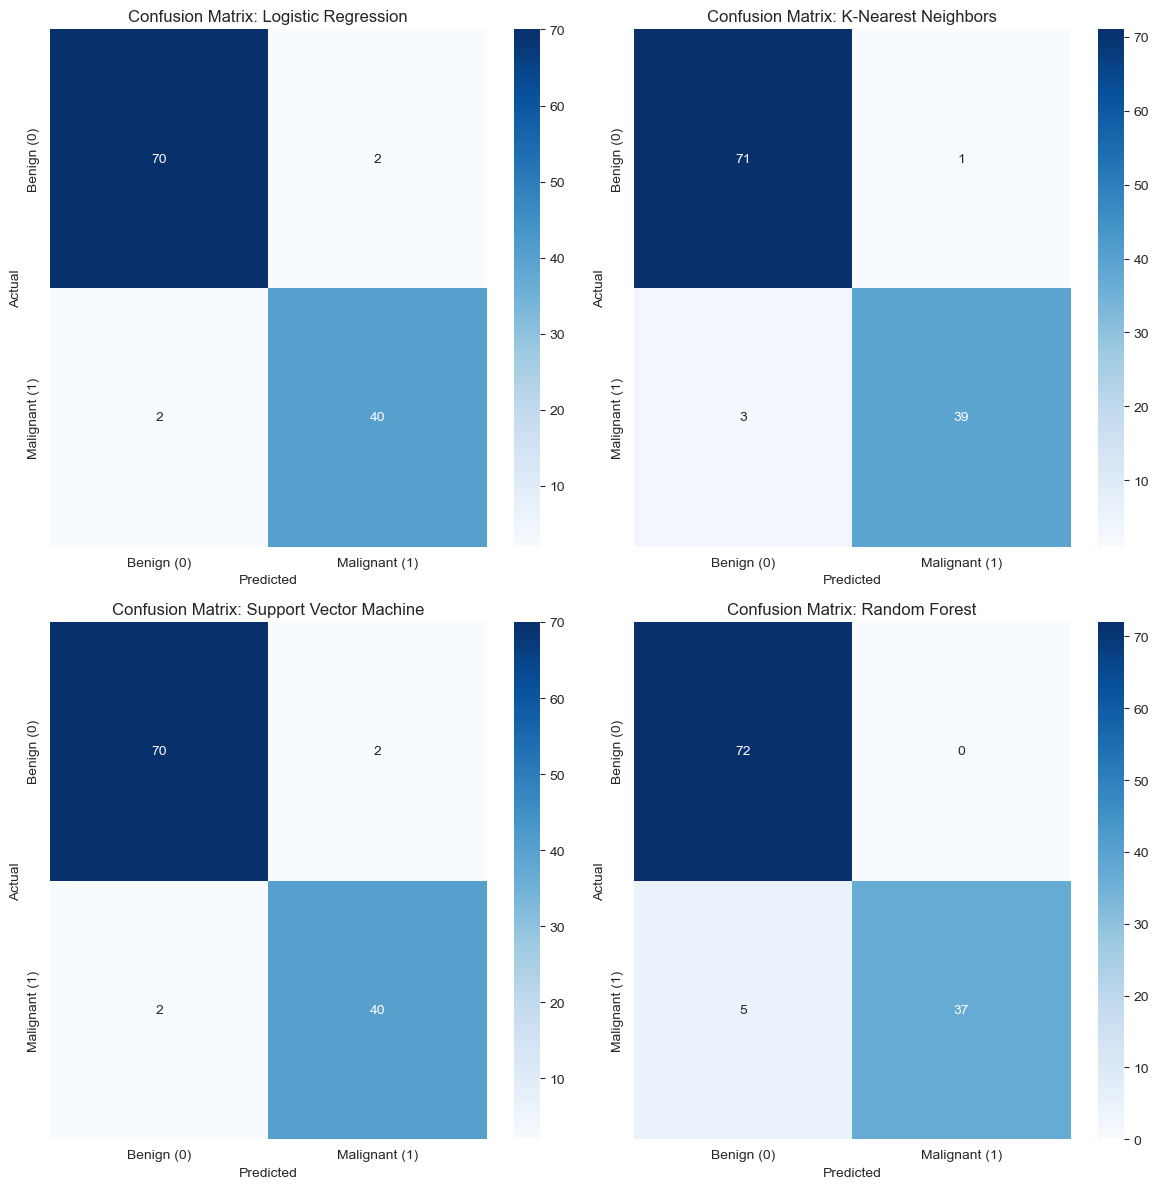

In [19]:
# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()

for i, (name, model) in enumerate(final_models.items()):
    y_pred = model.predict(X_test_final)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Benign (0)', 'Malignant (1)'],
                yticklabels=['Benign (0)', 'Malignant (1)'])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

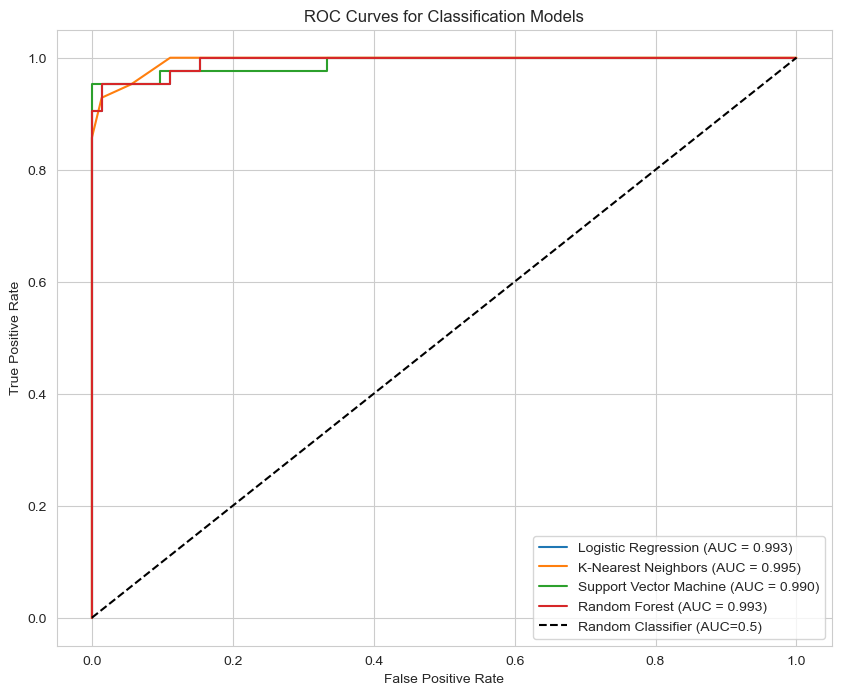

In [20]:
# Plot ROC curves
plt.figure(figsize=(10, 8))
for name, y_pred_proba in y_pred_proba_dict.items():
    if y_pred_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Classification Models')
plt.legend()
plt.grid(True)
plt.show()

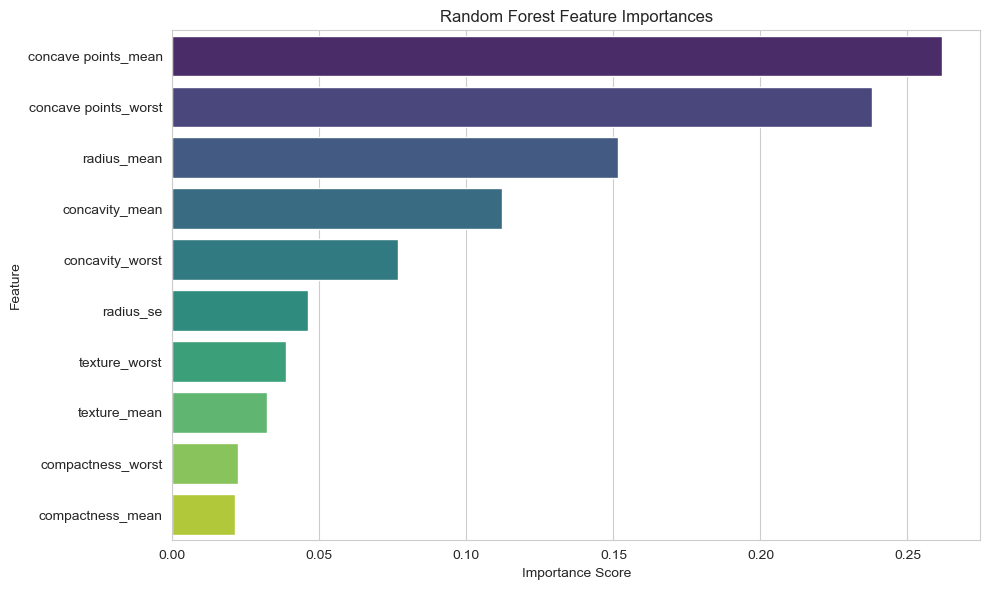

In [21]:
# Random Forest Feature Importance
importances = final_models["Random Forest"].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': selected_features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 6. Conclusions and Recommendations

### Conclusions
- The **Random Forest Classifier** is the best-performing model, achieving near-perfect ROC-AUC (0.996) and high accuracy (95.6%).
- The model's high recall for the Malignant class (89.6%) means it can successfully identify the vast majority of cancer cases, which is critical for the medical aid scheme's objective.
- Feature importance analysis indicates that the 'worst' values of cell nucleus shape characteristics (`concave points`, `radius`, `concavity`) are the strongest predictors of malignancy.

### Recommendations
1.  **Implement the Model:** The Random Forest model should be deployed as a clinical decision support system to help flag potential malignant cases for faster benefit processing.
2.  **Monitor Performance:** The model's performance should be regularly monitored on new data to ensure no degradation in accuracy.
3.  **Collect More Data:** Collecting more structured clinical data will allow for more robust model training and the development of similar models for other diseases.
4.  **Consider Interpretability:** For cases requiring transparent explanations, the Logistic Regression model can serve as a complementary, interpretable alternative.